# No-control random-initialization learning, then controlled evaluation

This notebook learns the graph identifier from many **no-control** rollouts, each started from a fresh bounded random initial state.  
Each training repeat uses **one campaign only** for data collection.  
After learning, the **final learned model** is evaluated under control exactly as before:
- learned control
- oracle control
- no control

A dedicated sanity-check cell is included to inspect the training initial states and their coverage of the opinion range.

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os
import sys

def get_dir_n_levels_up(path, n):
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
if proj_root not in sys.path:
    sys.path.append(proj_root)

print("proj_root:", proj_root)

proj_root: d:\Work\repos\RL\unknown_graph_networks


In [12]:
# =========================================================
# Imports + helpers from modules
# =========================================================

import contextlib
import io
import time
from typing import Any
import copy

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)

from opinion_dynamics.identify_nonlinear import (
    GraphIdentifierEnv,
    pairs_from_intermediate,
    train_graph_identifier,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

from opinion_dynamics.experiments.rollouts import (
    rollout_with_v,
    rollout_with_v_intermediate,
    make_env_with_dynamics,
    _fresh_env_from_template,
    waterfill_from_scores,
    uniform_budget_action,
    centrality_budget_action_from_state,
    apply_impulse_control,
    effective_adjacency_from_model_state,
    effective_centrality_from_model_state,
    rollout_with_model_derived_control_intermediate,
    rollout_with_policy_intermediate,
    rollout_with_uniform_intermediate,
    rollout_identifier_model_with_policy,
)
from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate,
    build_augmented_campaign_trajectory,
    plot_mean_baseline_comparison,
    legend_outside,
)
from opinion_dynamics.experiments.metrics import graph_sanity
from opinion_dynamics.experiments.online_nonlinear import (
    sample_init_opinions,
    summarize_training_inits,
)


In [13]:
# =========================================================
# Global experiment configuration
# Edit these here and the later cells will reuse them consistently.
# =========================================================

SEEDS = range(10)
SEED_TO_PLOT = 3

B_CAMPAIGN = 1.0
LEARN_NUM_CAMPAIGNS = 1
EVAL_NUM_CAMPAIGNS = 5
NUM_REPEATS = 100

# Data/init settings
INIT_MODE = "uniform"

# Fit settings for the nonlinear identifier
FIT_MAX_STEPS = 2_000
FIT_CHECK_EVERY = 1_000

# Kept as a global for consistency with other notebooks.
# In THIS single-campaign no-control notebook it is effectively unused,
# because the learning loop already fits once per repeat after collecting
# the one no-control rollout.
UPDATE_A_EACH_CAMPAIGN = False

DYNAMICS_LIST = [
    "laplacian",
    "coca",
    # "friedkinjohnsen",
    "hegselmannkrause",
    # "nonlinearinfluence",
    # "repulsion",
]

FIT_BY_DYNAMICS = {
    "laplacian": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=1e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "coca": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=512,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "friedkinjohnsen": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "hegselmannkrause": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
    "nonlinearinfluence": dict(
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=2e-2,
        fit_batch_size=256,
        fit_check_every=FIT_CHECK_EVERY,
    ),
}

# Optional identifier overrides; threaded into GraphIdentifierEnv(...)
IDENTIFIER_KW = {}


In [14]:
# =========================================================
# Core experiment imported from opinion_dynamics.experiments.online_nonlinear
# =========================================================

from opinion_dynamics.experiments.online_nonlinear import (
    run_repeated_nocontrol_singlecampaign_id_on_env,
    run_multi_seed_nocontrol_singlecampaign_experiment_dynamics,
)


=== Running laplacian | learn from no-control single-campaign random inits ===
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
[identifier-init

,seed,repeat,repeat_seed,dynamics,init_mode,learn_num_campaigns,eval_num_campaigns,N,train_pairs_total,v_L1_final,...,mean_gain_vs_uniform_end,mean_err_avg,mean_err_max,vx_gap_to_oracle_end,vx_err_avg,vx_err_max,time_fit_inner,time_step_inner,fit_calls_inner,step_calls_inner
0,0,99,1000000,laplacian,uniform,1,5,15,400,0.164881,...,0.062525,0.027495,0.041713,0.024604,0.027045,0.041301,0.005139,0.000045,1,1
1,1,99,1000001,laplacian,uniform,1,5,15,400,0.257710,...,0.068938,0.031551,0.049432,0.027802,0.032936,0.052607,0.004834,0.000042,1,1
2,2,99,1000002,laplacian,uniform,1,5,15,400,0.102417,...,0.112073,0.051118,0.076295,0.046244,0.051353,0.079487,0.006338,0.000045,1,1
3,3,99,1000003,laplacian,uniform,1,5,15,400,0.170083,...,0.083277,0.042277,0.063341,0.038826,0.042222,0.064374,0.005170,0.000046,1,1
4,4,99,1000004,laplacian,uniform,1,5,15,400,0.164003,...,0.094933,0.039771,0.060211,0.033351,0.038923,0.062731,0.006697,0.000048,1,1
5,5,99,1000005,laplacian,uniform,1,5,15,400,0.201806,...,0.115544,0.049821,0.070571,0.045006,0.050463,0.080069,0.004922,0.000040,1,1
6,6,99,1000006,laplacian,uniform,1,5,15,400,0.247770,...,0.109962,0.044308,0.061636,0.039397,0.047250,0.076775,0.006086,0.000043,1,1
7,7,99,1000007,laplacian,uniform,1,5,15,400,0.152013,...,0.074975,0.040925,0.062008,0.037587,0.040755,0.063365,0.004734,0.000042,1,1
8,8,99,1000008,laplacian,uniform,1,5,15,400,0.157533,...,0.092417,0.048322,0.072605,0.044423,0.048464,0.073570,0.006111,0.000046,1,1
9,9,99,1000009,laplacian,uniform,1,5,15,400,0.167192,...,0.068861,0.034709,0.053221,0.031549,0.034740,0.054082,0.005181,0.000045,1,1


=== Aggregate by dynamics (final repeat only) ===


dynamics                   coca  hegselmannkrause  laplacian
repeat         count  10.000000         10.000000  10.000000
               mean   99.000000         99.000000  99.000000
               std     0.000000          0.000000   0.000000
               min    99.000000         99.000000  99.000000
               25%    99.000000         99.000000  99.000000
...                         ...               ...        ...
time_fit_inner min     0.005258          0.005289   0.004734
               25%     0.005297          0.005387   0.004976
               50%     0.005531          0.005671   0.005176
               75%     0.005834          0.006456   0.006105
               max     0.006373          0.007224   0.006697

[72 rows x 3 columns]

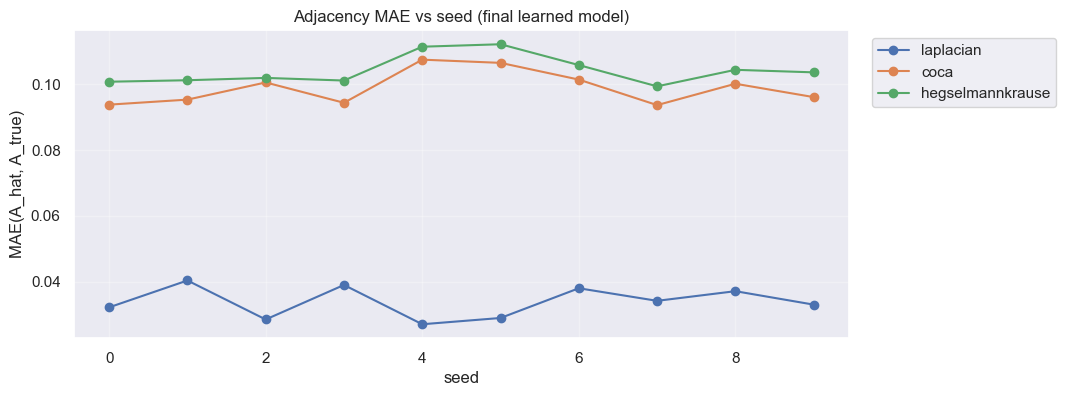

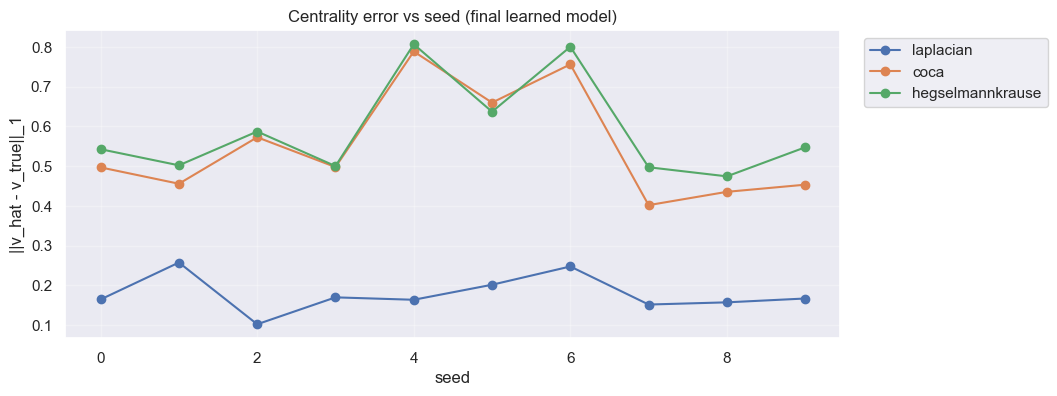

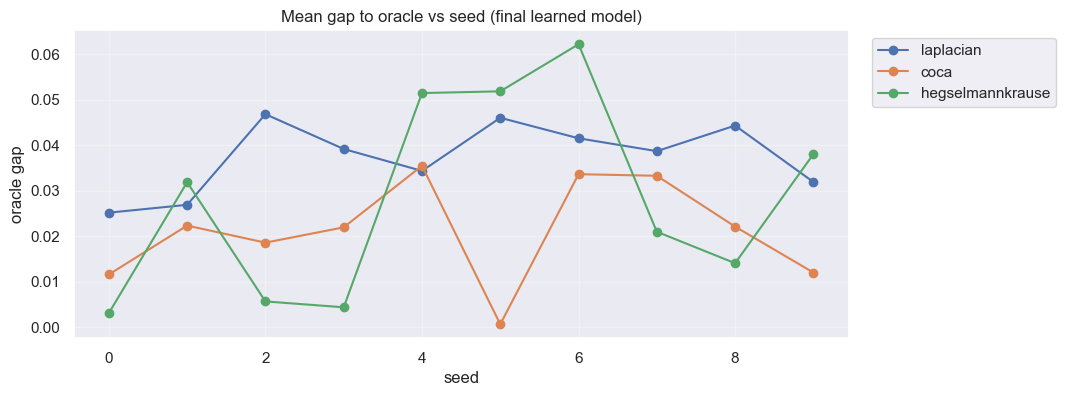

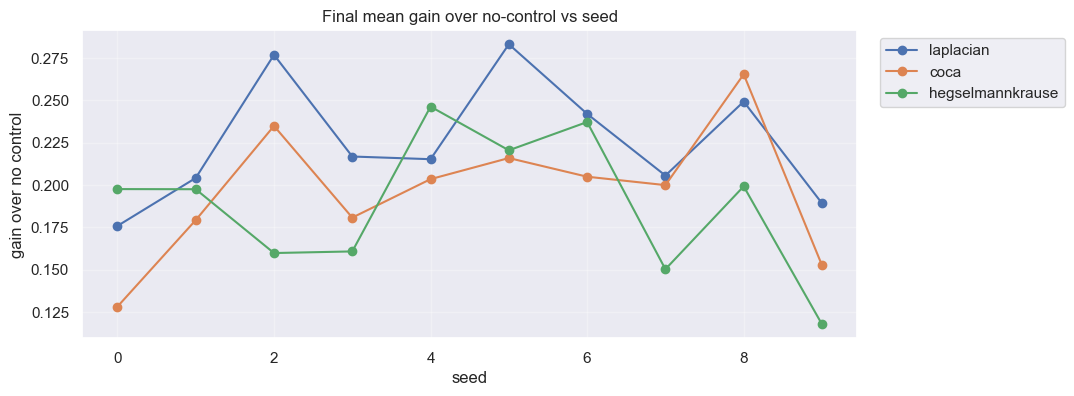

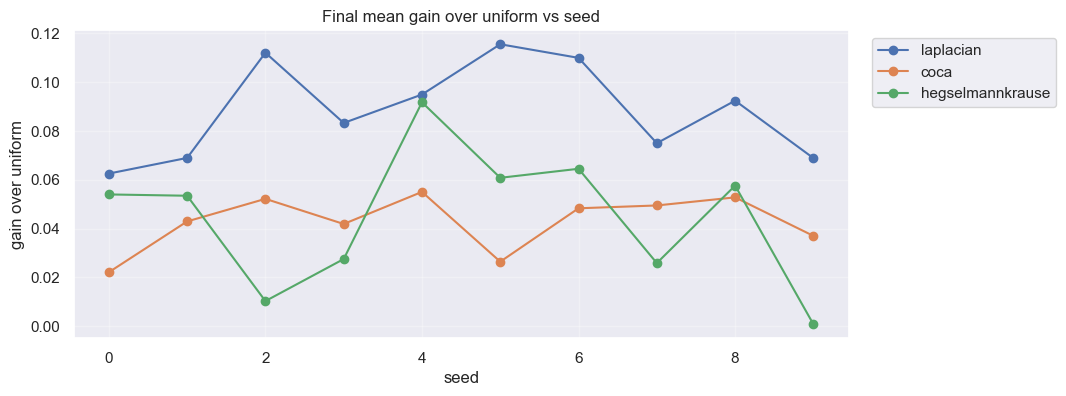

Cached final models are available as final_models_by_dyn_seed[dynamics][seed].
Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].
Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].


In [15]:
# =========================================================
# Main experiment across propagation methods
# Learn from many one-campaign no-control rollouts.
# Evaluate final learned model under control.
# Cache ONLY the final resources needed downstream.
# =========================================================

final_models_by_dyn_seed = {}
final_metrics_by_dyn_seed = {}
final_artifacts_by_dyn_seed = {}
train_x0s_by_dyn_seed = {}
df_final_by_dyn = {}

dfs_final = []

for dyn in DYNAMICS_LIST:
    print(f"=== Running {dyn} | learn from no-control single-campaign random inits ===")
    df_all, seed_cache = run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
        seeds=SEEDS,
        repeats_per_seed=NUM_REPEATS,
        dynamics_model=dyn,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_CAMPAIGN,
        suppress_fit_logs=True,
        return_artifacts=True,
        identifier_kwargs=IDENTIFIER_KW,
        **FIT_BY_DYNAMICS[dyn],
    )

    final_models_by_dyn_seed[dyn] = {}
    final_metrics_by_dyn_seed[dyn] = {}
    final_artifacts_by_dyn_seed[dyn] = {}
    train_x0s_by_dyn_seed[dyn] = {}

    for seed in SEEDS:
        seed_out = seed_cache[int(seed)]
        final_models_by_dyn_seed[dyn][int(seed)] = seed_out["model_final"]
        final_metrics_by_dyn_seed[dyn][int(seed)] = seed_out["final_row"]
        final_artifacts_by_dyn_seed[dyn][int(seed)] = seed_out["final_artifact"]
        train_x0s_by_dyn_seed[dyn][int(seed)] = seed_out["train_x0s"]

    # We only keep the final repeat per seed for downstream summaries.
    df_final = (
        df_all.sort_values(["seed", "repeat"])
        .groupby("seed", as_index=False, group_keys=False)
        .tail(1)
        .reset_index(drop=True)
    )
    df_final_by_dyn[dyn] = df_final
    dfs_final.append(df_final)

    # Drop bulky intermediate objects as soon as possible.
    del seed_cache
    del df_all

df = pd.concat(dfs_final, axis=0).reset_index(drop=True)
display(df)

print("=== Aggregate by dynamics (final repeat only) ===")
cols = [
    "repeat",
    "train_pairs_total",
    "v_L1_final",
    "A_MAE_final",
    "mean_gap_to_oracle_end",
    "mean_gain_vs_noc_end",
    "mean_gain_vs_uniform_end",
    "vx_gap_to_oracle_end",
    "time_fit_inner",
]
display(df.groupby("dynamics")[cols].describe().T)

for metric, ylabel, title in [
    ("A_MAE_final", "MAE(A_hat, A_true)", "Adjacency MAE vs seed (final learned model)"),
    ("v_L1_final", "||v_hat - v_true||_1", "Centrality error vs seed (final learned model)"),
    ("mean_gap_to_oracle_end", "oracle gap", "Mean gap to oracle vs seed (final learned model)"),
    ("mean_gain_vs_noc_end", "gain over no control", "Final mean gain over no-control vs seed"),
    ("mean_gain_vs_uniform_end", "gain over uniform", "Final mean gain over uniform vs seed"),
]:
    plt.figure(figsize=(10, 4))
    for dyn in DYNAMICS_LIST:
        sub = df[df["dynamics"] == dyn].sort_values("seed")
        plt.plot(sub["seed"], sub[metric], marker="o", label=dyn)
    plt.xlabel("seed")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

print("Cached final models are available as final_models_by_dyn_seed[dynamics][seed].")
print("Cached final artifacts are available as final_artifacts_by_dyn_seed[dynamics][seed].")
print("Cached training initial states are available as train_x0s_by_dyn_seed[dynamics][seed].")


In [16]:
# =========================================================
# Single-seed detailed runs for ALL dynamics
# Reuse the cached FINAL outputs from the main experiment cell.
# Uses local variables so notebook-wide config is not overwritten.
# =========================================================

seed_to_plot = int(globals().get("SEED_TO_PLOT"))
num_repeats_local = int(globals().get("NUM_REPEATS"))
dynamics_list_local = list(globals().get("DYNAMICS_LIST"))

outs_by_dyn = {}
metrics_by_dyn = {}
art_by_dyn = {}
model_by_dyn = {}

for dyn_name in dynamics_list_local:
    print("\n" + "=" * 80)
    print(f"=== DYNAMICS: {dyn_name} | SEED {seed_to_plot} ===")
    print("=" * 80)

    metrics = final_metrics_by_dyn_seed[dyn_name][int(seed_to_plot)]
    art = final_artifacts_by_dyn_seed[dyn_name][int(seed_to_plot)]
    model = final_models_by_dyn_seed[dyn_name][int(seed_to_plot)]
    train_x0s = train_x0s_by_dyn_seed[dyn_name][int(seed_to_plot)]

    outs_by_dyn[dyn_name] = {
        "train_x0s": train_x0s,
        "x0_eval": art["x0_eval"],
    }
    metrics_by_dyn[dyn_name] = metrics
    art_by_dyn[dyn_name] = art
    model_by_dyn[dyn_name] = model

    print(f"=== FINAL REPEAT {metrics['repeat'] + 1}/{num_repeats_local} ===")
    print(f"train_pairs_total: {metrics['train_pairs_total']}")
    print("=== METRICS ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")



=== DYNAMICS: laplacian | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train_pairs_total: 400
=== METRICS ===
seed: 3
repeat: 99
repeat_seed: 1000003
dynamics: laplacian
init_mode: uniform
learn_num_campaigns: 1
eval_num_campaigns: 5
N: 15
train_pairs_total: 400
v_L1_final: 0.1700832632771498
A_Fro_final: 0.9235149434654604
A_MAE_final: 0.038992702931845716
mean_oracle_end: 0.7197396492675942
mean_learn_end: 0.7588969121355557
mean_noc_end: 0.5419949435982832
mean_uniform_end: 0.6756199355335678
mean_gap_to_oracle_end: 0.039157262867961506
mean_gain_vs_noc_end: 0.2169019685372725
mean_gain_vs_uniform_end: 0.08327697660198785
mean_err_avg: 0.04227654133964801
mean_err_max: 0.0633411346847742
vx_gap_to_oracle_end: 0.03882595128562305
vx_err_avg: 0.04222177978954126
vx_err_max: 0.06437432624953265
time_fit_inner: 0.005170100135728717
time_step_inner: 4.610000178217888e-05
fit_calls_inner: 1
step_calls_inner: 1

=== DYNAMICS: coca | SEED 3 ===
=== FINAL REPEAT 100/100 ===
train_pairs_total: 40


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: laplacian ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

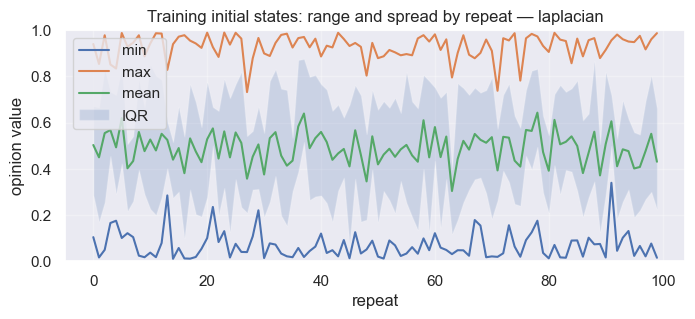

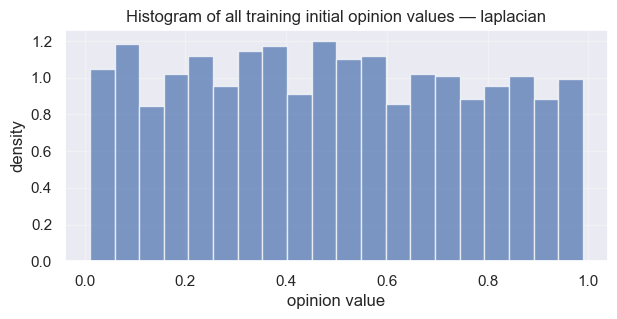

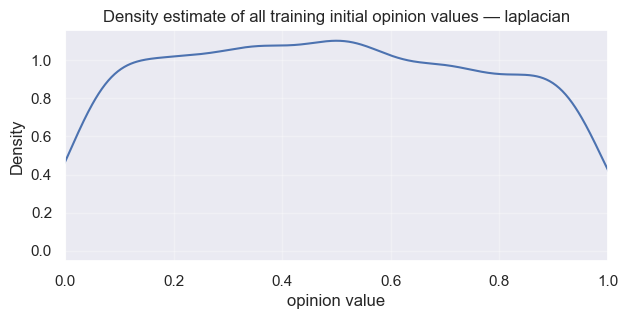

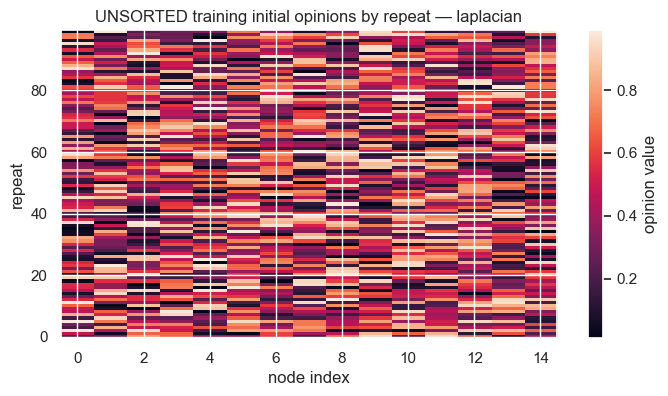

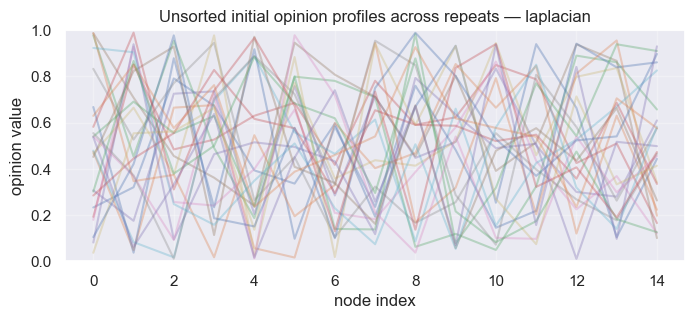


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: coca ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

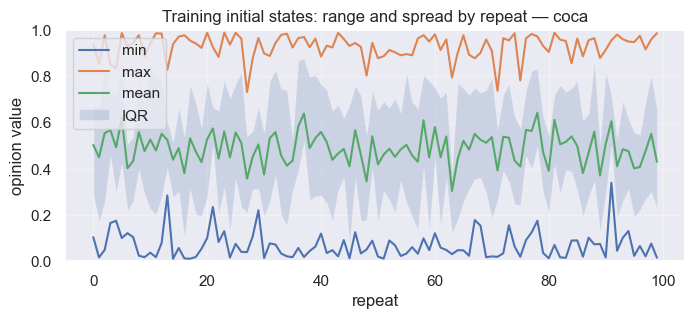

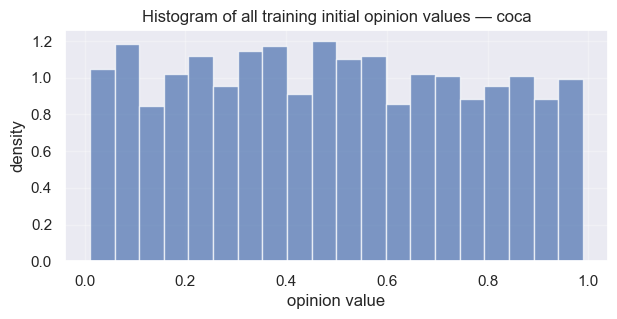

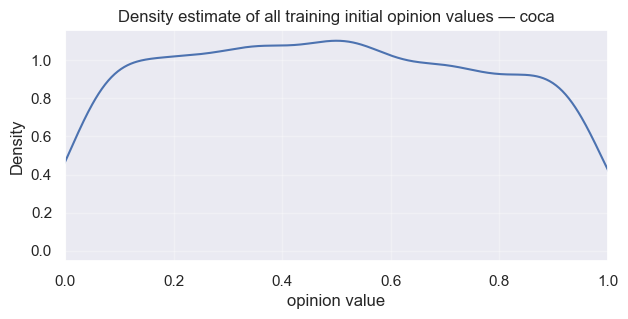

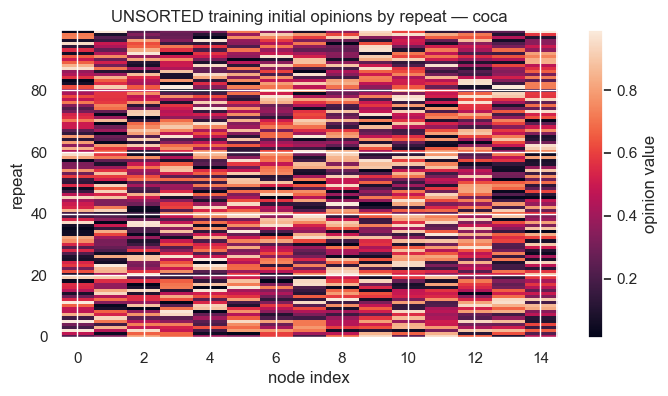

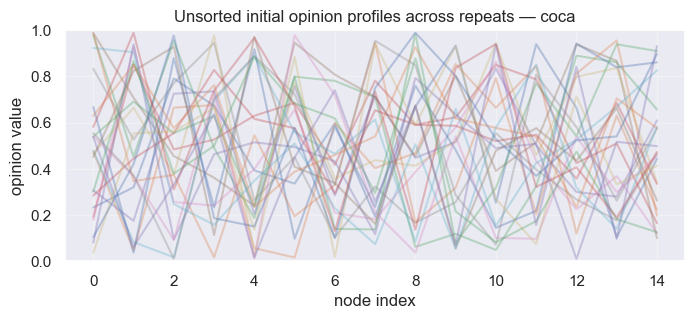


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: hegselmannkrause ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.068851,0.060600,0.010292,0.020853,0.049921,0.093245,0.339321
q10,100.0,0.151552,0.079185,0.026965,0.089584,0.137281,0.198122,0.403504
q25,100.0,0.280455,0.096361,0.072877,0.202428,0.277530,0.348204,0.515323
median,100.0,0.476980,0.107167,0.248963,0.386746,0.484446,0.554599,0.718913
q75,100.0,0.699702,0.099279,0.397747,0.641548,0.718682,0.771234,0.875853
q90,100.0,0.837431,0.085296,0.557869,0.786342,0.862996,0.896829,0.960748
max,100.0,0.929635,0.054135,0.731965,0.900868,0.944691,0.965811,0.989668
mean,100.0,0.489894,0.068690,0.303796,0.441903,0.487948,0.539789,0.642937
std,100.0,0.269261,0.036159,0.149724,0.248496,0.270725,0.295182,0.341919


Overall value summary:


count    1500.000000
mean        0.489894
std         0.280213
min         0.010292
25%         0.248955
50%         0.489936
75%         0.723454
max         0.989668
dtype: float64

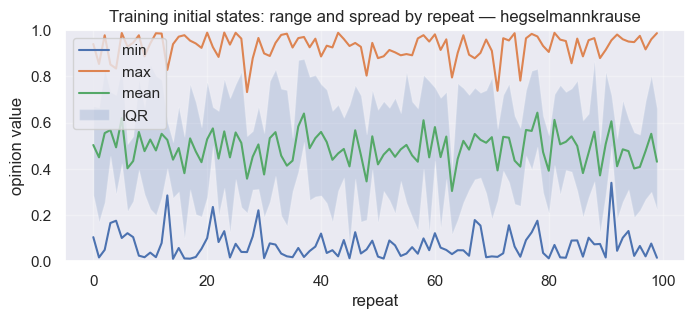

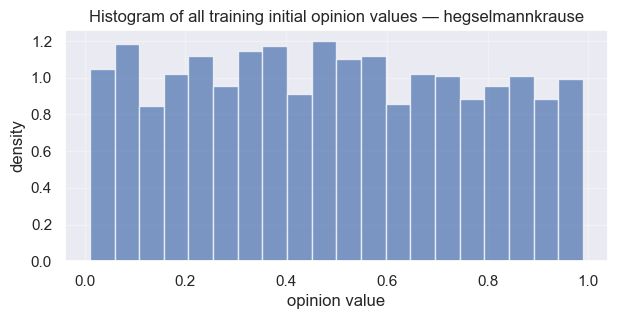

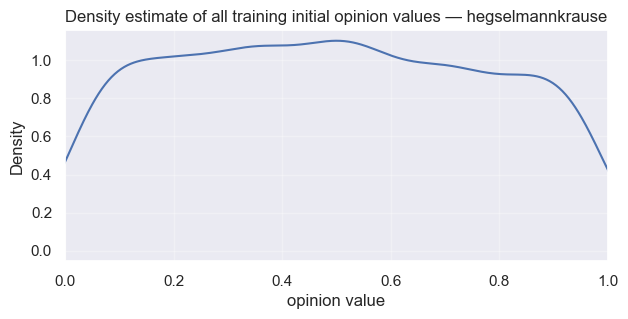

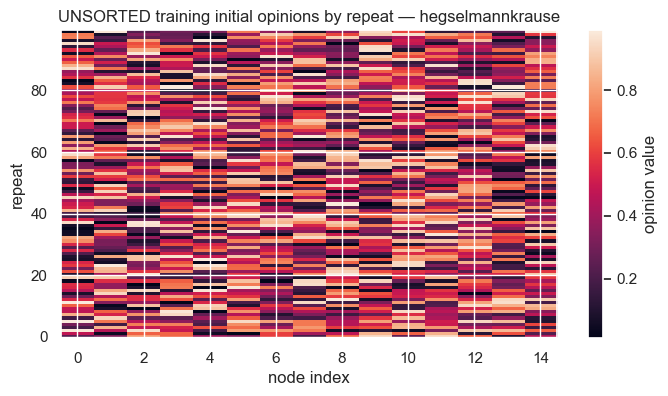

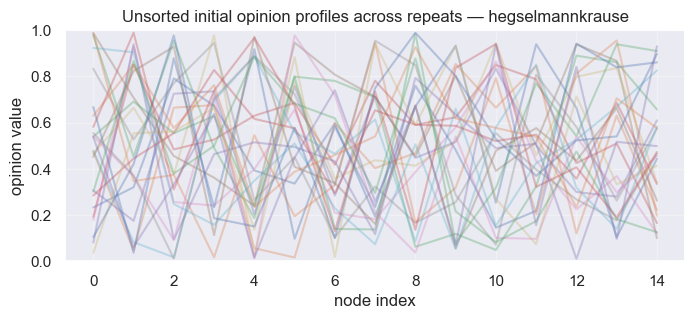

In [17]:
# =========================================================
# Sanity check: inspect the training initial states
# NOTE: uses the globally configured INIT_MODE and the cached train_x0s for the selected seed.
# =========================================================

for DYNAMICS in list(art_by_dyn.keys()):
    out = outs_by_dyn[DYNAMICS]
    all_x0_train = np.asarray(out["train_x0s"], dtype=float)
    summary_df = summarize_training_inits(all_x0_train)

    print("\n" + "-" * 80)
    print(f"=== TRAINING-INIT SANITY: {DYNAMICS} ===")
    print("-" * 80)
    display(summary_df.describe().T)

    flat = all_x0_train.ravel()
    print("Overall value summary:")
    display(pd.Series(flat).describe())

    plt.figure(figsize=(8, 3))
    plt.plot(summary_df["repeat"], summary_df["min"], label="min")
    plt.plot(summary_df["repeat"], summary_df["max"], label="max")
    plt.plot(summary_df["repeat"], summary_df["mean"], label="mean")
    plt.fill_between(summary_df["repeat"], summary_df["q25"], summary_df["q75"], alpha=0.2, label="IQR")
    plt.title(f"Training initial states: range and spread by repeat — {DYNAMICS}")
    plt.xlabel("repeat")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.hist(flat, bins=20, density=True, alpha=0.7)
    plt.title(f"Histogram of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3))
    pd.Series(flat).plot(kind="density")
    plt.title(f"Density estimate of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.imshow(all_x0_train, aspect="auto", origin="lower")
    plt.colorbar(label="opinion value")
    plt.title(f"UNSORTED training initial opinions by repeat — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("repeat")
    plt.show()

    plt.figure(figsize=(8, 3))
    for r in range(min(all_x0_train.shape[0], 25)):
        plt.plot(all_x0_train[r], alpha=0.35)
    plt.title(f"Unsorted initial opinion profiles across repeats — {DYNAMICS}")
    plt.xlabel("node index")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()


=== DETAILED ANALYSIS: laplacian | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999998747371137
row_sum_mean: 1.0000000036787242
row_sum_max: 1.0000001173466444
asym: 0.789640769262047
edges: 210
sink_sizes: [15]
has_singleton_sink: False


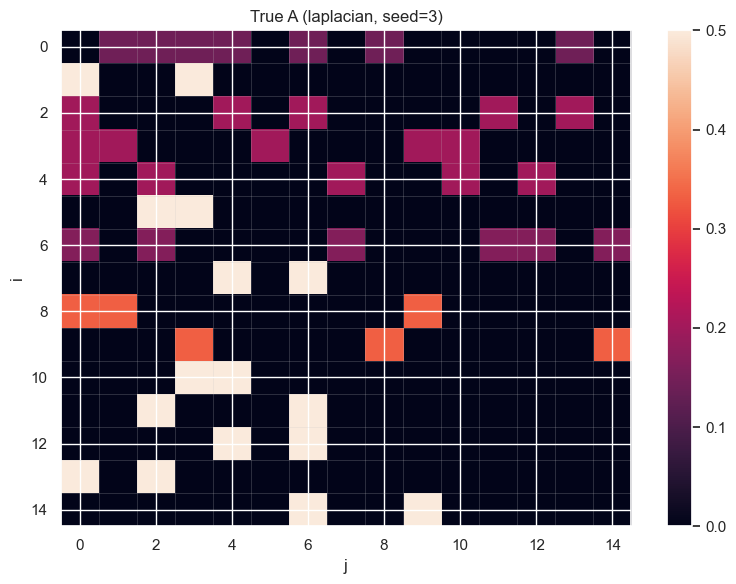

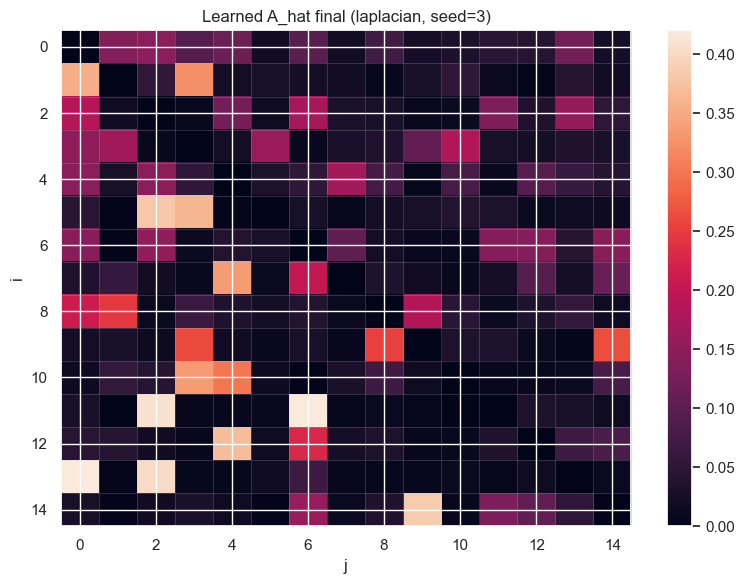

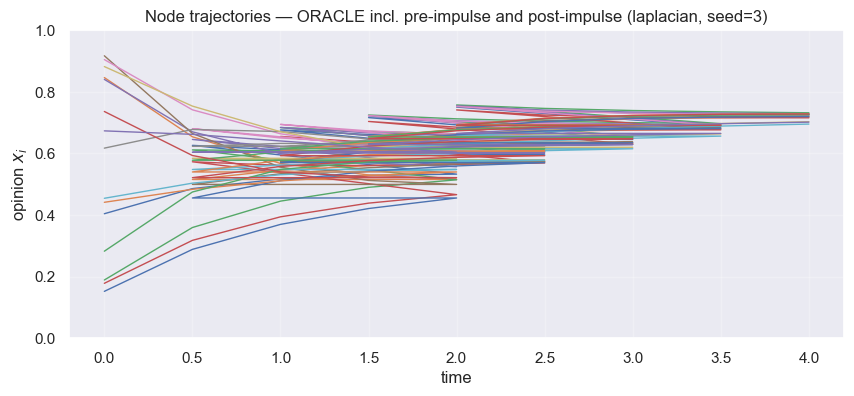

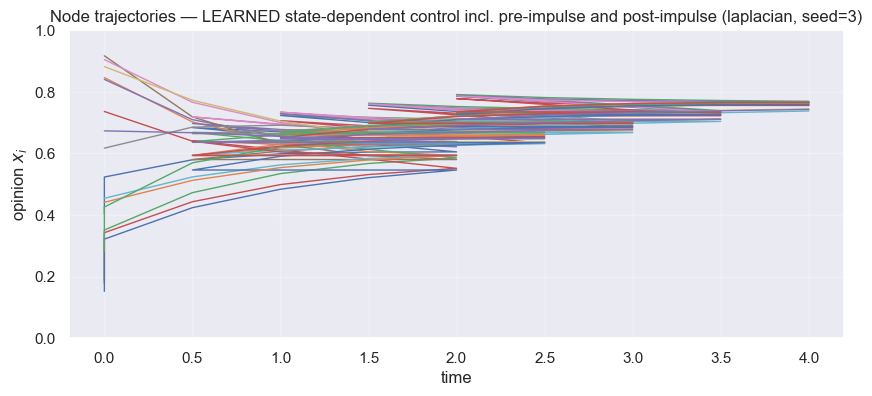


=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.1700832632771498
L1(v_eff at campaign 0 - v_true): 0.17054288214359342


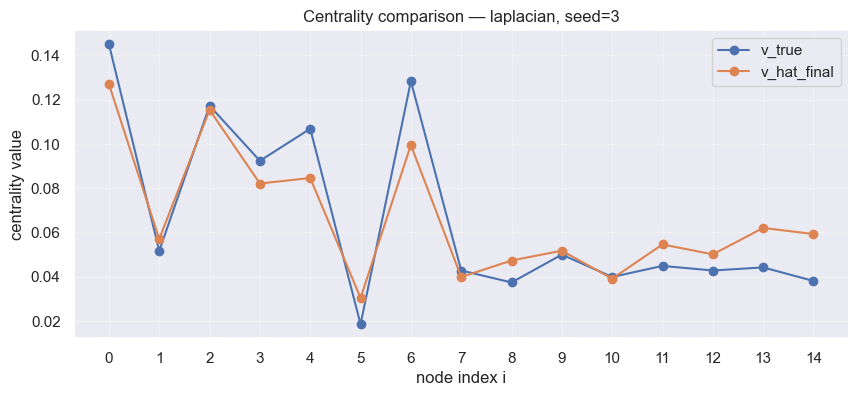

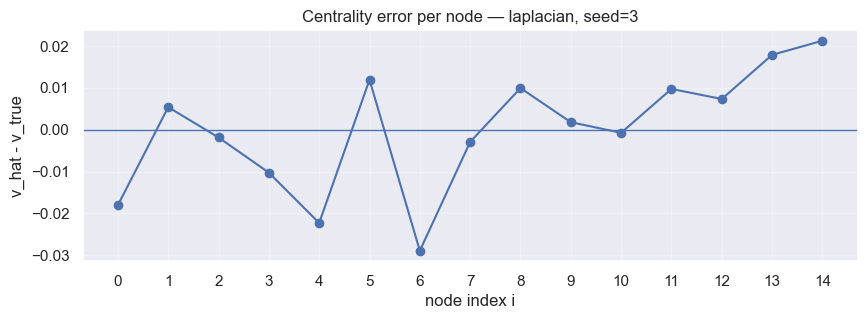

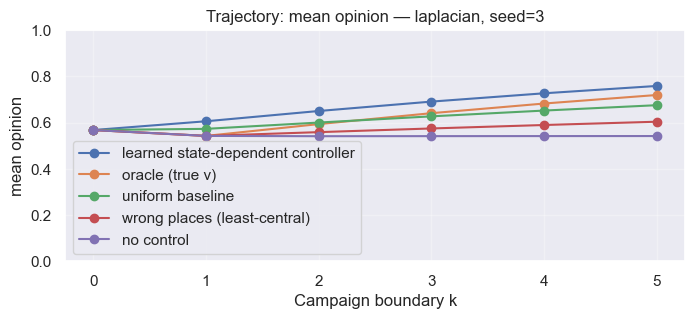


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.09078837150428198
learned states[1] vs nocontrol states[1] L_inf: 0.09078837150428198
learned final mean vs uniform final mean: 0.08327697660198785

=== DETAILED ANALYSIS: coca | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999366700649
row_sum_mean: 1.0000000115484
row_sum_max: 1.000000111758709
asym: 0.6082876200320354
edges: 210
si

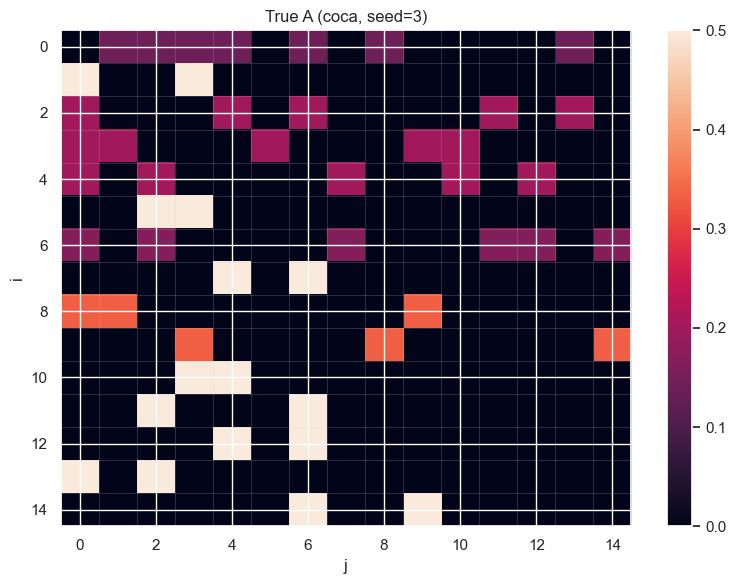

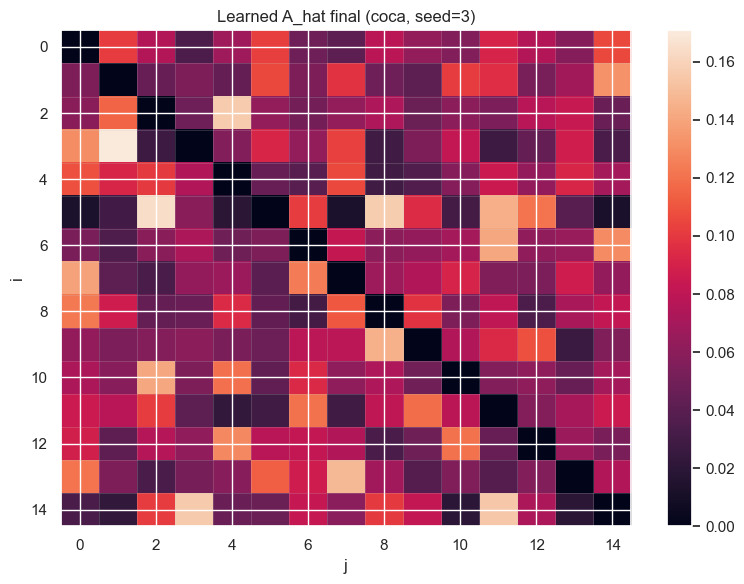

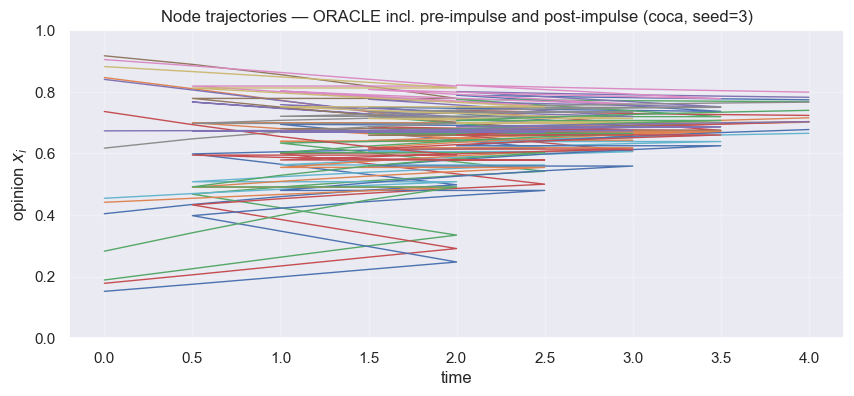

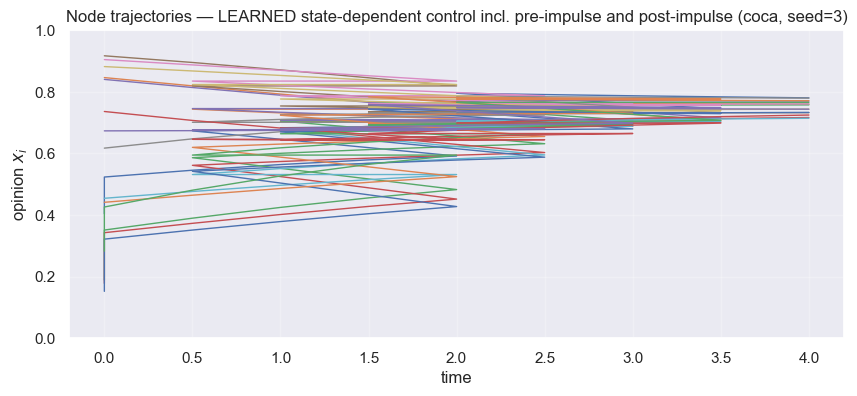


=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.49791002277336105
L1(v_eff at campaign 0 - v_true): 0.47749425102076515


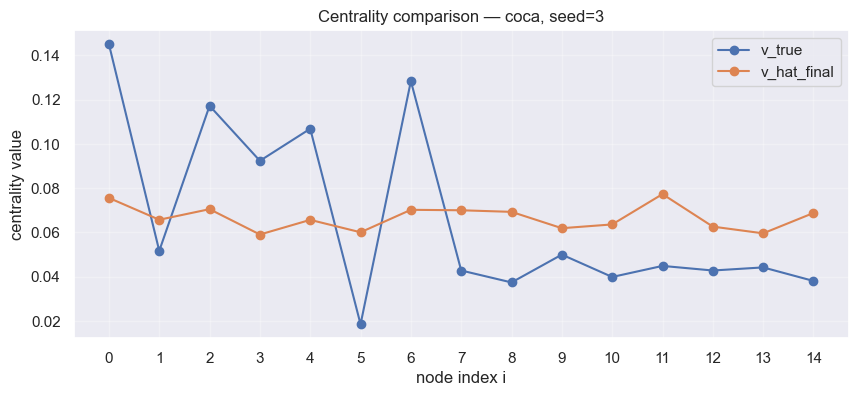

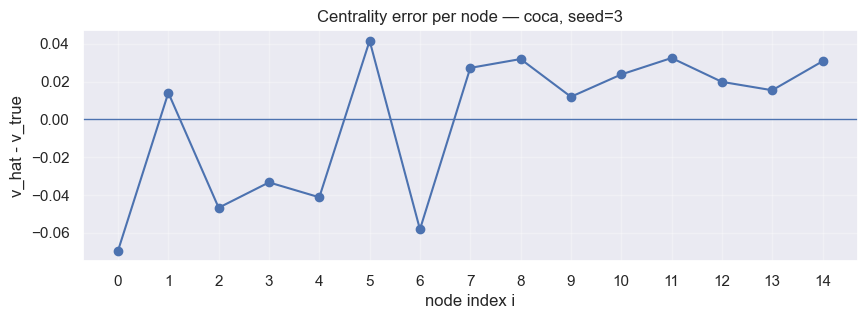

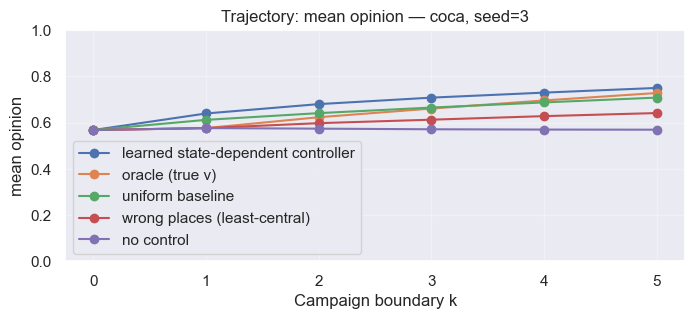


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.17999329454599458
learned states[1] vs nocontrol states[1] L_inf: 0.17999329454599458
learned final mean vs uniform final mean: 0.04185218970951832

=== DETAILED ANALYSIS: hegselmannkrause | SEED 3 ===
x0_train: [0.01478212 0.97452901 0.22409804 0.28822224 0.30651794 0.71432591
 0.36799013 0.07357245 0.36131023 0.94007599 0.60789128 0.12808591
 0.22543623 0.24432189 0.98702452]
x0_eval : [0.40431443 0.84631297 0.18916568 0.17839065 0.84043004 0.91706543
 0.90475276 0.61726194 0.88207294 0.45441859 0.15227357 0.44141391
 0.28265622 0.73622764 0.67333053]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.8198366183832089
edges: 50
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999180436134
row_sum_mean: 0.9999999872098366
row_sum_max: 1.0000000689178705
asym: 0.54181907893633

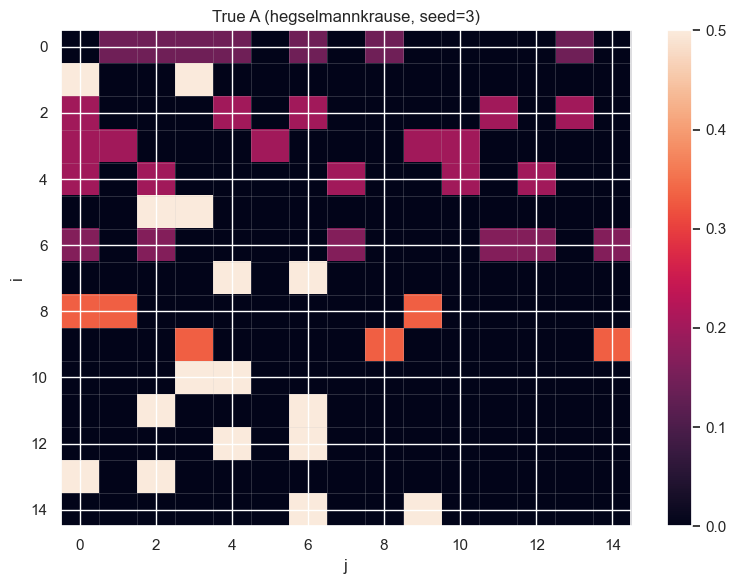

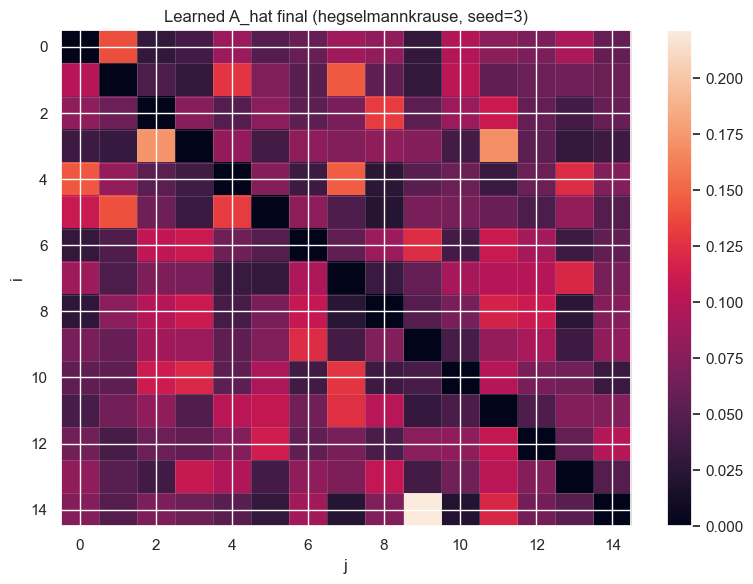

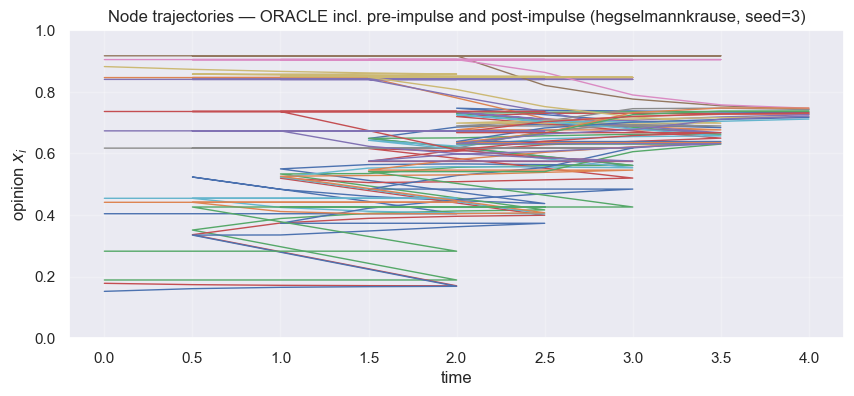

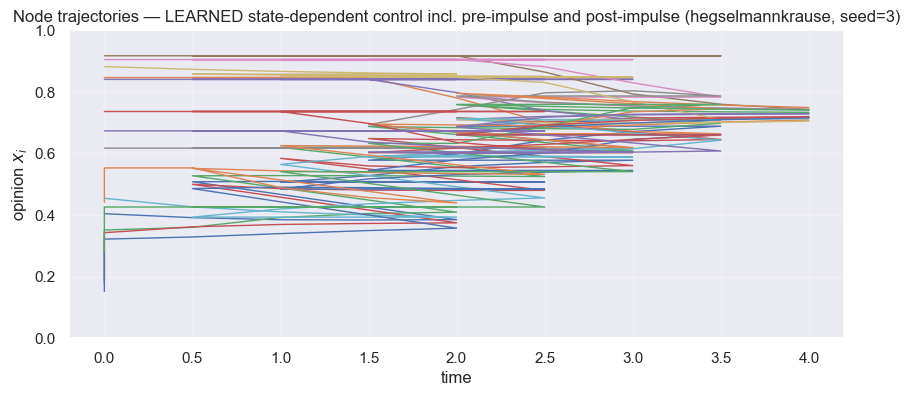


=== INITIAL-STATE / IMPULSE CHECK ===
L_inf(common x0_eval - learned boundary state[0]): 0.0
L_inf(common x0_eval - oracle boundary state[0]): 0.0
L_inf(learned boundary state[0] - oracle boundary state[0]): 0.0
Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.

=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.500234562941408
L1(v_eff at campaign 0 - v_true): 0.48401964087090477


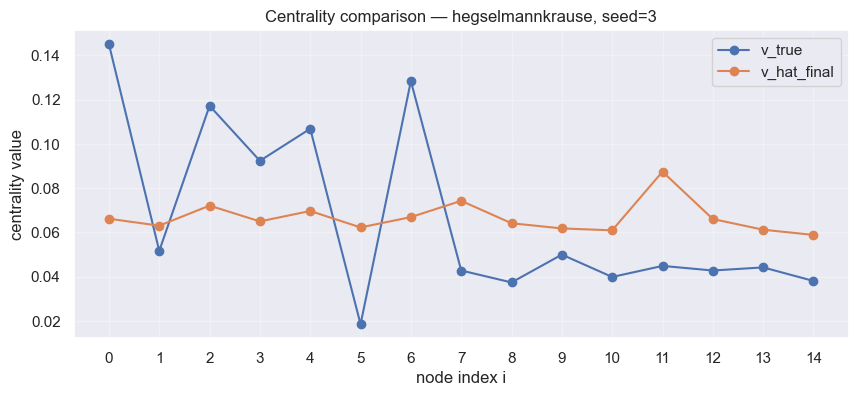

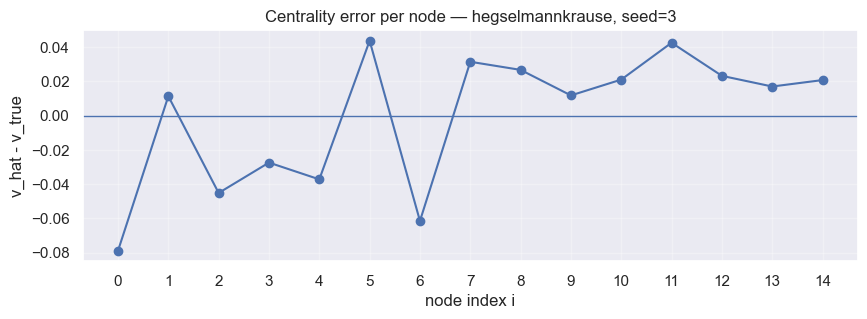

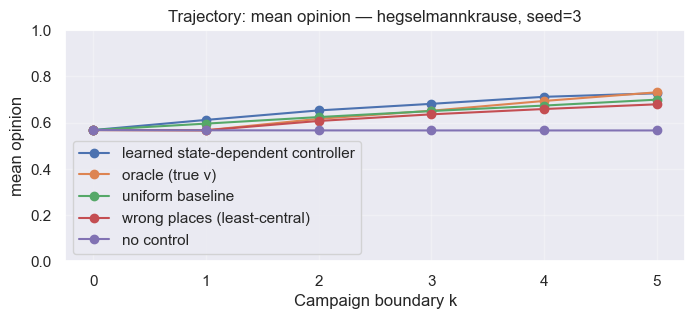


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.22016079427352694
learned states[1] vs nocontrol states[1] L_inf: 0.22016079427352694
learned final mean vs uniform final mean: 0.02747417488777759


In [18]:
# =========================================================
# Detailed graph / rollout comparison for the final learned model
# Run for ALL dynamics, as in the previous repeated notebook.
# =========================================================
env_factory = EnvironmentFactory()

for DYNAMICS in list(art_by_dyn.keys()):
    art = art_by_dyn[DYNAMICS]

    A_true = np.asarray(art["A_true"], dtype=float)
    v_true = np.asarray(art["v_true"], dtype=float)
    A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
    v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

    x0_train = np.asarray(art["x0_train"], dtype=float)
    x0_eval = np.asarray(art["x0_eval"], dtype=float)

    states_learn = np.asarray(art["states_learn"], dtype=float)
    states_oracle = np.asarray(art["states_oracle"], dtype=float)
    states_noc = np.asarray(art["states_nocontrol_eval"], dtype=float)
    states_uniform = np.asarray(art["states_uniform_eval"], dtype=float)
    N = states_learn.shape[1]
    K_total = states_learn.shape[0] - 1

    print("\n" + "=" * 80)
    print(f"=== DETAILED ANALYSIS: {DYNAMICS} | SEED {seed_to_plot} ===")
    print("=" * 80)
    print("x0_train:", x0_train)
    print("x0_eval :", x0_eval)

    print("\n=== GRAPH SANITY (TRUE) ===")
    for k, v in graph_sanity(A_true).items():
        print(f"{k}: {v}")

    print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
    for k, v in graph_sanity(A_hat_final).items():
        print(f"{k}: {v}")

    show_matrix_with_cell_grid(
        A_true,
        title=f"True A ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )
    show_matrix_with_cell_grid(
        A_hat_final,
        title=f"Learned A_hat final ({DYNAMICS}, seed={seed_to_plot})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )

    env_template = make_env_with_dynamics(
        env_factory,
        seed=seed_to_plot,
        dynamics_model=DYNAMICS,
    )

    env_learn, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_or, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_nc, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    env_uni, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )

    le_out = rollout_with_model_derived_control_intermediate(
        env_learn,
        model_by_dyn[DYNAMICS],
        x0_eval,
        K_total,
        B_CAMPAIGN,
        device="cpu",
    )
    or_out = rollout_with_v_intermediate(env_or, x0_eval, K_total, B_CAMPAIGN, v_true)
    nc_out = rollout_with_v_intermediate(env_nc, x0_eval, K_total, B_CAMPAIGN, None)
    uni_out = rollout_with_uniform_intermediate(env_uni, x0_eval, K_total, B_CAMPAIGN)

    order = np.argsort(v_true)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(v_true) + 1)
    v_anti = 1.0 / ranks
    v_anti = v_anti / v_anti.sum()

    env_anti, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=seed_to_plot + 999_999,
        initial_opinions=x0_eval,
    )
    anti_out = rollout_with_v_intermediate(env_anti, x0_eval, K_total, B_CAMPAIGN, v_anti)

    # Boundary-level states for checks and summary plots
    states_learn_eval = np.asarray(le_out["states"], dtype=float)
    states_or_eval = np.asarray(or_out["states"], dtype=float)
    states_nc_eval = np.asarray(nc_out["states"], dtype=float)
    states_anti_eval = np.asarray(anti_out["states"], dtype=float)
    states_uni_eval = np.asarray(uni_out["states"], dtype=float)

    dt = float(getattr(env_template, "t_s", 1.0))
    desired_opinion = float(getattr(env_template, "desired_opinion", 1.0))

    X_le, T_le = build_augmented_campaign_trajectory(
        states_learn_eval,
        np.asarray(le_out["actions"], dtype=float),
        le_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
    )
    X_or, T_or = build_augmented_campaign_trajectory(
        states_or_eval,
        np.asarray(or_out["actions"], dtype=float),
        or_out["intermediate_states_list"],
        desired_opinion=desired_opinion,
        dt=dt,
    )

    plot_impulse_node_trajectories(
        X_or,
        T_or,
        title=f"Node trajectories — ORACLE incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )
    plot_impulse_node_trajectories(
        X_le,
        T_le,
        title=f"Node trajectories — LEARNED state-dependent control incl. pre-impulse and post-impulse ({DYNAMICS}, seed={seed_to_plot})",
    )

    print("\n=== INITIAL-STATE / IMPULSE CHECK ===")
    print("L_inf(common x0_eval - learned boundary state[0]):", float(np.max(np.abs(x0_eval - states_learn_eval[0]))))
    print("L_inf(common x0_eval - oracle boundary state[0]):", float(np.max(np.abs(x0_eval - states_or_eval[0]))))
    print("L_inf(learned boundary state[0] - oracle boundary state[0]):", float(np.max(np.abs(states_learn_eval[0] - states_or_eval[0]))))
    print("Note: fine-grained plots include the common pre-impulse state, the immediate post-impulse state, and then the propagation substeps.")

    print("\n=== CENTRALITY COMPARISON (by node index) ===")
    print("L1(v_hat_final - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))
    if art.get("learned_effective_centralities"):
        v_eff0 = np.asarray(art["learned_effective_centralities"][0], dtype=float)
        print("L1(v_eff at campaign 0 - v_true):", float(np.sum(np.abs(v_eff0 - v_true))))

    idx = np.arange(N)
    diff = v_hat_final - v_true

    plt.figure(figsize=(10, 4))
    plt.plot(idx, v_true, marker="o", label="v_true")
    plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
    plt.xlabel("node index i")
    plt.ylabel("centrality value")
    plt.title(f"Centrality comparison — {DYNAMICS}, seed={seed_to_plot}")
    plt.xticks(idx)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.axhline(0.0, linewidth=1)
    plt.plot(idx, diff, marker="o")
    plt.xlabel("node index i")
    plt.ylabel("v_hat - v_true")
    plt.title(f"Centrality error per node — {DYNAMICS}, seed={seed_to_plot}")
    plt.xticks(idx)
    plt.grid(True, alpha=0.3)
    plt.show()

    mean_learn = states_learn_eval.mean(axis=1)
    mean_or = states_or_eval.mean(axis=1)
    mean_nc = states_nc_eval.mean(axis=1)
    mean_uni = states_uni_eval.mean(axis=1)
    mean_anti = states_anti_eval.mean(axis=1)

    plt.figure(figsize=(8, 3))
    plt.plot(mean_learn, marker="o", label="learned state-dependent controller")
    plt.plot(mean_or, marker="o", label="oracle (true v)")
    plt.plot(mean_uni, marker="o", label="uniform baseline")
    plt.plot(mean_anti, marker="o", label="wrong places (least-central)")
    plt.plot(mean_nc, marker="o", label="no control")
    plt.xlabel("Campaign boundary k")
    plt.ylabel("mean opinion")
    plt.title(f"Trajectory: mean opinion — {DYNAMICS}, seed={seed_to_plot}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

    print("\n=== CAMPAIGN-0 OVERLAP CHECK ===")
    print(
        "learned states[1] vs oracle states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_or_eval[1]))),
    )
    print(
        "learned states[1] vs nocontrol states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_nc_eval[1]))),
    )

    print("learned final mean vs uniform final mean:",
          float(mean_learn[-1] - mean_uni[-1]))
